## 7. Number of arms per com events

In [1]:
%reload_ext autoreload
%autoreload 2

In [93]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import starbars
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_figures.figure3d import find_theta_dynamics_animals
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (return_num_of_arms,
    return_meta_data, GLM_max_proportion, model2numbers, violin_plot)
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (
GLM_correctness, GLM_correctness_by_animal, GLM_correctness_remote, correct_future_2_arm_rep)

In [6]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
remote_parameter = f"dur_{minimum_duration_remote}_sum_{min_posterior}"

### Home versus outer well

In [193]:
success = {}
for animal in ["klein","julio"]: 
    (num_of_arms, remote_time_spent,
     contain_long_theta, contain_home,
     remote_arm_content, remote_trial_infos,
     rewards) = return_num_of_arms(animal, list_of_days_animals[animal])

    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_count_{animal}'
    data = {"num_of_arms": num_of_arms,
            "contain_home": contain_home,
            "remote_time_spent":remote_time_spent,
            "contain_long_theta": contain_long_theta,
            "remote_arm_content": remote_arm_content,
            "rewards": rewards,
            "remote_trial_infos": remote_trial_infos}
    file_path = output_folder + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    success[animal] = 1

[2026-04-06 08:49:41,127][WARNING]: Skipped checksum for file with hash: 7508ee83-f898-2a0f-e6a4-0487d3f4eed3, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_N76BDIBUF6.nwb


klein20231101_.nwb


[08:49:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-06 08:49:50,340][WARNING]: Skipped checksum for file with hash: 342c9de9-3d78-ec96-b2b7-092a5d206739, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_PN2LVHEYUR.nwb
[2026-04-06 08:49:50,348][WARNING]: Skipped checksum for file with hash: 342c9de9-3d78-ec96-b2b7-092a5d206739, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_PN2LVHEYUR.nwb
[2026-04-06 08:49:50,355][WARNING]: Skipped checksum for file with hash: 342c9de9-3d78-ec96-b2b7-092a5d206739, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_PN2LVHEYUR.nwb
[2026-04-06 08:49:50,359][WARNING]: Skipped checksum for file with hash: 342c9de9-3d78-ec96-b2b7-092a

remote_interval_identities [3 4 3]
parsing multiple change of mind
parsing multiple change of mind
remote_interval_identities [3]
parsing multiple change of mind
remote_interval_identities [3]
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
remote_interval_identities [3 4]
parsing multiple change of mind
remote_interval_identities [4 4 4]
parsing multiple change of mind


[2026-04-06 08:49:50,784][WARNING]: Skipped checksum for file with hash: 9a7d808d-5d11-1e2e-2b3d-2000bf7ed186, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_X1X7465EER.nwb


...

parsing multiple change of mind
remote_interval_identities [0 0 0]
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
remote_interval_identities [3 3]


[09:04:42][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-06 09:04:42,702][WARNING]: Skipped checksum for file with hash: 58b13fef-e456-ed7e-1d54-b2a4f421a01f, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_1M5066DGJ1.nwb
[2026-04-06 09:04:42,710][WARNING]: Skipped checksum for file with hash: 58b13fef-e456-ed7e-1d54-b2a4f421a01f, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_1M5066DGJ1.nwb
[2026-04-06 09:04:42,719][WARNING]: Skipped checksum for file with hash: 58b13fef-e456-ed7e-1d54-b2a4f421a01f, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_1M5066DGJ1.nwb
[2026-04-06 09:04:42,723][WARNING]: Skipped checksum for file with hash: 58b13fef-e456-ed7e-1d54-b2a4

parsing multiple change of mind
parsing multiple change of mind
julio20230811_.nwb
No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 2, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 6, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}


[09:04:54][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-06 09:04:54,226][WARNING]: Skipped checksum for file with hash: 0c2c1874-1a73-9755-fa77-283a9cf0317e, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_ZS628HNU00.nwb
[2026-04-06 09:04:54,234][WARNING]: Skipped checksum for file with hash: 0c2c1874-1a73-9755-fa77-283a9cf0317e, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_ZS628HNU00.nwb
[2026-04-06 09:04:54,241][WARNING]: Skipped checksum for file with hash: 0c2c1874-1a73-9755-fa77-283a9cf0317e, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_ZS628HNU00.nwb
[2026-04-06 09:04:54,246][WARNING]: Skipped checksum for file with hash: 0c2c1874-1a73-9755-fa77-283a

remote_interval_identities [4 4]
parsing multiple change of mind
remote_interval_identities [0]
parsing multiple change of mind
data saved to /stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_count_julio.pkl


In [128]:
#%debug

In [194]:
success

{'klein': 1, 'julio': 1}

### Plot histogram of number of arms of replayed

In [195]:
num_of_arms = {}
contain_home = {}
contain_long_theta = {}
time_spent = {}
rewards = {}

for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_count_{animal}'
    file_path = output_folder + '.pkl'

    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    num_of_arms[animal] = data["num_of_arms"]
    contain_home[animal] = data["contain_home"]
    contain_long_theta[animal] = data["contain_long_theta"]
    time_spent[animal] = data["remote_time_spent"]
    rewards[animal] = data["rewards"]
    

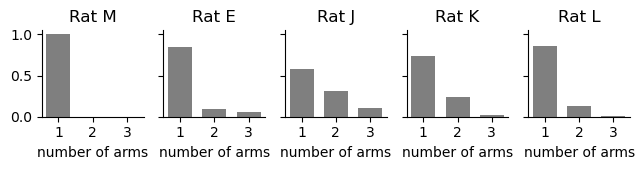

In [307]:
# excludes the current arm animal is in
animals = ["molly", "eliot", "julio", "klein", "lewis"]

x = [1,2,3,4]
fig, axes = plt.subplots(1,len(animals), figsize=(1.3*len(animals), 1.8), sharey = True)
animal_ind = 0
for animal in animals:
    data1 = np.array(num_of_arms[animal])
    data_local = np.array(contain_long_theta[animal]) > 0
    data_home = np.array(contain_home[animal]) > 0
    data1[data_local] -= 1
    data1[data_home] -= 1
    ind = data1 > 0

    
    data1 = data1[ind]
    axes[animal_ind].hist(data1, color = "k", alpha = 0.5, rwidth=0.7,
                          weights = np.ones_like(data1)/len(data1), bins = x)

    axes[animal_ind].set_xticks(np.array(x[:-1]) + 0.5)
    axes[animal_ind].set_xticklabels(np.array(x[:-1]))
    axes[animal_ind].set_xlabel("number of arms")
    axes[animal_ind].set_title(f"Rat {animal[0].upper()}")
    axes[animal_ind].spines['top'].set_visible(False)
    axes[animal_ind].spines['right'].set_visible(False)
    
    animal_ind += 1
plt.tight_layout()

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/"
plt.savefig(file_path + f'histogram_of_remote_arm_rep_exluding_current_arm.pdf',bbox_inches='tight')

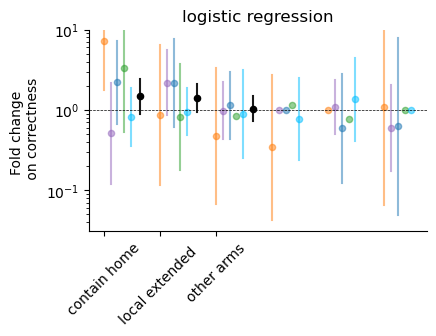

In [227]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,1,figsize=(5, 4))

dx = 0.12
for animal_ind,animal in enumerate(animals):
    results_animal = results_animals[animal]
    
    #### axis 1
    coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(results_animal)
    coef_est = np.exp(coef_est)
    coef_pd = np.exp(coef_pd)
    CI = np.exp(CI)

    for (coef_ind, coef_name) in enumerate(coef_names):
        axes.scatter(coef_ind+dx*animal_ind, coef_est[coef_ind],
                     alpha = 0.5,
                     color = color_by_rat[animal], s = 20)
        axes.plot([coef_ind+dx*animal_ind, coef_ind + dx * animal_ind],[CI.loc[coef_name][0], CI.loc[coef_name][1]],
                  color = color_by_rat[animal], alpha = 0.5)
    
    # for coef_ind in range(len(pvalues)):
    #     pvalue = pvalues[coef_ind]
    #     if pvalue < 0.05:
    #         starbars.draw_annotation([(coef_ind+dx*animal_ind, coef_ind+dx*animal_ind, np.round(pvalue, 4))], ax = axes, color = 'k')

# for all animals
#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

dx = 0.13
animal_ind += 1
for (coef_ind, coef_name) in enumerate(coef_names):
    axes.scatter(coef_ind+dx*animal_ind, coef_est[coef_ind], color = "k", s = 20)
    axes.plot([coef_ind+dx*animal_ind, coef_ind + dx * animal_ind],[CI.loc[coef_name][0], CI.loc[coef_name][1]],
                  color = "k", alpha = 0.9)
    

    
axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
axes.set_title("logistic regression")
axes.set_ylabel("Fold change \n on correctness")
axes.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes.set_yscale('log') 
#axes.set_xlim([-0.5,2.5])
axes.set_ylim([0,4.2])
axes.set_yticks([0.1, 1, 10])


for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind+dx*animal_ind,
                                   coef_ind+dx*animal_ind, np.round(pvalue, 4))], ax = axes, color = 'k')

# theta_point_est = coef_pd.loc["local extended"]
# theta_CI = CI.loc["local extended"]
# print(f"Fold change of the effect of long theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 
    
axes.spines[['right', 'top']].set_visible(False)
    
file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/by_animal_extra_correctness_number_of_arms_GLM.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

In [146]:
animals = ["molly","eliot","lewis","julio","klein"]

dt = 0.38
dx= 0.05

GLM_xy = []
reward_talley_h_animals = {}
reward_talley_nh_animals = {}

ax = axes
animal_ind = 0
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                     minimum_duration = minimum_duration, min_posterior= min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    
    features_all, response_all = data["features_all"], data["response_all"]
    trial_info_all = data["home_trial_info_all"]
    reward = [_[-1] for _ in trial_info_all]

    reward_talley_h = np.zeros((len(reward), 6)) + np.nan
    reward_talley_nh = np.zeros((len(reward), 6)) + np.nan

    contain_home = data["home_replay_all"]

    animal_category = [a == animal for a in animals]
    for ind in range(len(contain_home)):
        occurance = np.array(response_all[ind]).reshape((1,-1)) @ features_all[ind]
        occurance = occurance.ravel()
        if contain_home[ind]:
            reward_talley_h[ind] = np.array([reward[ind] if occurance[c] else np.nan for c in range(6)])
        else:
            reward_talley_nh[ind] = np.array([reward[ind] if occurance[c] else np.nan for c in range(6)])
        
        # GLM_xy.append(animal_category + [
        #     contain_home[ind] * features_all[ind, 0],
        #     contain_home[ind] * features_all[ind, 1],
        #     contain_home[ind] * features_all[ind, 2],
        #     contain_home[ind] * features_all[ind, 3],
        #     reward[ind]
        # ])
    reward_talley_h_animals[animal] = reward_talley_h
    reward_talley_nh_animals[animal] = reward_talley_nh

# GLM_xy = np.array(GLM_xy)

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM


### Compare general occurence with home and those without home

In [149]:
def mean_sd_err_p(arr):
    p = np.mean(arr)
    N = len(arr)
    std = np.sqrt(p * (1-p) / N)
    return p, std

def mean_sd_err(arr):
    p = np.mean(arr)
    std = np.std(arr)/np.sqrt(len(arr))
    return p, std
    
from spyglass.shijiegu.changeOfMind import nodes, color_by_rat

In [153]:
num_of_arms = {}
contain_home = {}
contain_long_theta = {}
time_spent = {}
rewards = {}

for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_count_{animal}'
    file_path = output_folder + '.pkl'

    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    num_of_arms[animal] = data["num_of_arms"]
    contain_home[animal] = data["contain_home"]
    contain_long_theta[animal] = data["contain_long_theta"]
    time_spent[animal] = data["remote_time_spent"]
    rewards[animal] = data["rewards"]
    

molly
eliot
julio
klein
lewis


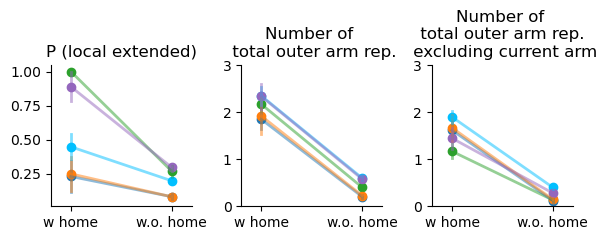

In [154]:
animals = ["molly", "eliot", "julio", "klein", "lewis"]

fig, axes = plt.subplots(1,3, figsize=(6, 2.5))
animal_ind = 0
for animal in animals:
    home = np.array(contain_home[animal]) > 0
    long_theta = np.array(contain_long_theta[animal])
    num = np.array(num_of_arms[animal])

    #### local extended long theta
    print(animal)
    data1 = long_theta[home]
    data2 = long_theta[~home]
    m1, sd1 = mean_sd_err_p(data1)
    m2, sd2 = mean_sd_err_p(data2)

    ax = axes[0]
    ax.plot([0, 1],[m1, m2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.scatter([0, 1],[m1, m2], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.set_title("P (local extended)")
    ax.set_xticks([0,1])
    ax.set_xlim([-0.2, 1.2])
    ax.set_xticklabels(["w home","w.o. home"])
    ax.spines[['right', 'top']].set_visible(False)

    #### Number of outer arms represented
    data1 = num[home]
    data2 = num[~home]
    m1, sd1 = mean_sd_err(data1)
    m2, sd2 = mean_sd_err(data2)

    ax = axes[1]
    ax.plot([0, 1],[m1, m2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.scatter([0, 1],[m1, m2], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.set_title("Number of \n total outer arm rep.")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1,2,3])
    ax.set_xlim([-0.2, 1.2])
    ax.set_xticklabels(["w home","w.o. home"])
    ax.spines[['right', 'top']].set_visible(False)

    #### Number of outer arms represented, excluding current
    num[long_theta > 0] -= 1
    data1 = num[home]
    data2 = num[~home]
    m1, sd1 = mean_sd_err(data1)
    m2, sd2 = mean_sd_err(data2)

    ax = axes[2]
    ax.plot([0, 1],[m1, m2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.scatter([0, 1],[m1, m2], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.set_title("Number of \n total outer arm rep. \n excluding current arm")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1,2,3])
    ax.set_xlim([-0.2, 1.2])
    ax.set_xticklabels(["w home","w.o. home"])
    
    
    # print("p(local-extended) on trials with home rep. ", np.mean(data1))
    # print("p(local-extended) on trials without home", np.mean(data2))

    # print("Outer arm num represented on trials with home", np.mean(num[home]-1))
    # print("Outer arm num represented on trials without home", np.mean(num[~home]))

    # print("\n")
    ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout() 
file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/home_vs_nohome.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")
   

## End here

### Reward rate vs number of arms

molly: 50 events with arm content.
molly
molly
eliot: 53 events with arm content.
eliot
eliot
julio: 33 events with arm content.
julio
julio
klein: 182 events with arm content.
klein
klein
lewis: 149 events with arm content.
lewis
lewis


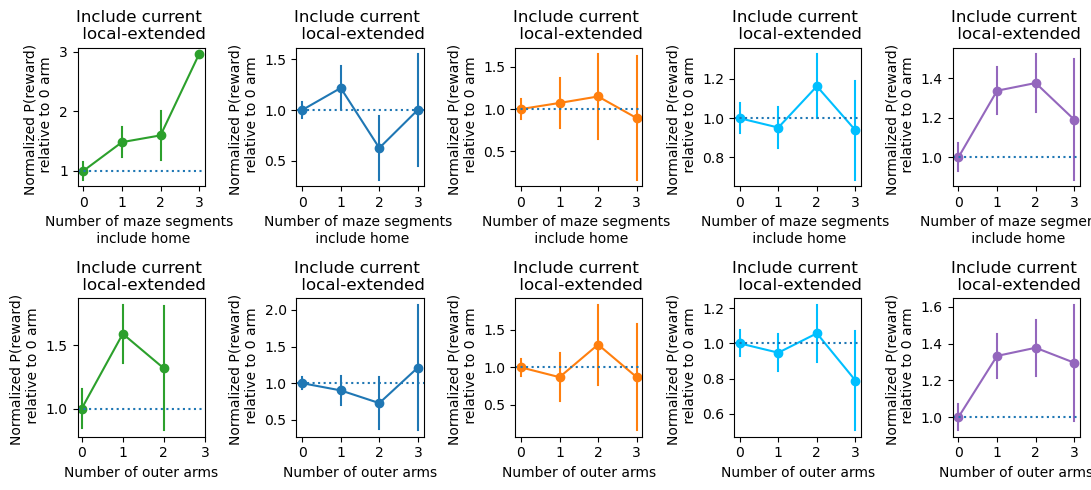

In [155]:
animals = ["molly", "eliot", "julio", "klein", "lewis"]

fig, axes = plt.subplots(2,len(animals), figsize=(11, 5))
animal_ind = 0
for animal in animals:
    home = np.array(contain_home[animal]) > 0
    long_theta = np.array(contain_long_theta[animal])
    num = np.array(num_of_arms[animal])
    reward = np.array(rewards[animal])
    #num[home] -= 1
    print(f"{animal}: {len(num[num > 0])} events with arm content.")

    #### local extended long theta
    print(animal)
    data1 = reward[num == 0]
    data2 = reward[num == 1]
    data3 = reward[num == 2]
    data4 = reward[num == 3]
    m1_, sd1 = mean_sd_err(data1)
    m1, sd1 = mean_sd_err(data1/m1_)
    m2, sd2 = mean_sd_err(data2/m1_)
    m3, sd3 = mean_sd_err(data3/m1_)
    m4, sd4 = mean_sd_err(data4/m1_)

    ax = axes[0, animal_ind]
    ax.plot([0, 1, 2, 3],[m1, m2, m3, m4], color = color_by_rat[animal])
    ax.scatter([0, 1, 2, 3],[m1, m2, m3, m4], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal])
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal])
    ax.plot([2, 2],[m3 - sd3, m3 + sd3], color = color_by_rat[animal])
    ax.plot([3, 3],[m4 - sd4, m4 + sd4], color = color_by_rat[animal])
    ax.set_title("Include current \n local-extended")
    ax.set_xticks([0,1,2,3])
    ax.set_xticklabels(["0","1","2","3"])
    ax.set_xlabel("Number of maze segments \n include home")
    ax.set_ylabel("Normalized P(reward) \n relative to 0 arm")
    ax.axhline(1,linestyle = ":")

    num = np.array(num_of_arms[animal])
    reward = np.array(rewards[animal])
    num[home] -= 1

    #### local extended long theta
    print(animal)
    data1 = reward[num == 0]
    data2 = reward[num == 1]
    data3 = reward[num == 2]
    data4 = reward[num == 3]
    m1_, sd1 = mean_sd_err(data1)
    m1, sd1 = mean_sd_err(data1/m1_)
    m2, sd2 = mean_sd_err(data2/m1_)
    m3, sd3 = mean_sd_err(data3/m1_)
    m4, sd4 = mean_sd_err(data4/m1_)

    ax = axes[1, animal_ind]
    ax.plot([0, 1, 2, 3],[m1, m2, m3, m4], color = color_by_rat[animal])
    ax.scatter([0, 1, 2, 3],[m1, m2, m3, m4], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal])
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal])
    ax.plot([2, 2],[m3 - sd3, m3 + sd3], color = color_by_rat[animal])
    ax.plot([3, 3],[m4 - sd4, m4 + sd4], color = color_by_rat[animal])
    ax.set_title("Include current \n local-extended")
    ax.set_xticks([0,1,2,3])
    ax.set_xticklabels(["0","1","2","3"])
    ax.set_xlabel("Number of outer arms")
    ax.set_ylabel("Normalized P(reward) \n relative to 0 arm")
    ax.axhline(1,linestyle = ":")

    animal_ind += 1

plt.tight_layout()  

molly
molly
eliot
eliot
julio
julio
klein
klein
lewis
lewis


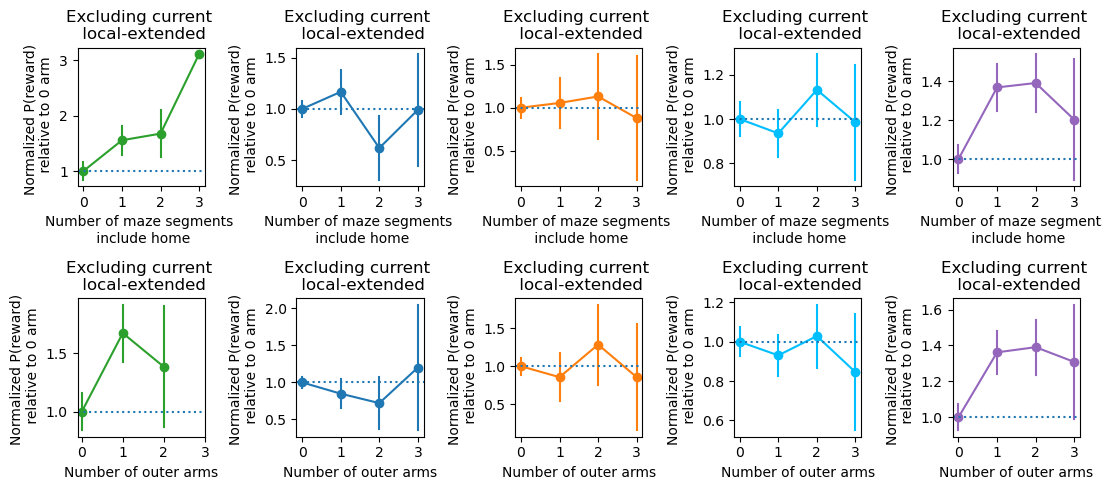

In [156]:
animals = ["molly", "eliot", "julio", "klein", "lewis"]

fig, axes = plt.subplots(2,len(animals), figsize=(11, 5))
animal_ind = 0
for animal in animals:
    home = np.array(contain_home[animal]) > 0
    long_theta = np.array(contain_long_theta[animal])
    num = np.array(num_of_arms[animal])
    reward = np.array(rewards[animal])
    #num[home] -= 1
    num[long_theta] -= 1

    #### local extended long theta
    print(animal)
    data1 = reward[num == 0]
    data2 = reward[num == 1]
    data3 = reward[num == 2]
    data4 = reward[num == 3]
    m1_, sd1 = mean_sd_err(data1)
    m1, sd1 = mean_sd_err(data1/m1_)
    m2, sd2 = mean_sd_err(data2/m1_)
    m3, sd3 = mean_sd_err(data3/m1_)
    m4, sd4 = mean_sd_err(data4/m1_)

    ax = axes[0, animal_ind]
    ax.plot([0, 1, 2, 3],[m1, m2, m3, m4], color = color_by_rat[animal])
    ax.scatter([0, 1, 2, 3],[m1, m2, m3, m4], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal])
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal])
    ax.plot([2, 2],[m3 - sd3, m3 + sd3], color = color_by_rat[animal])
    ax.plot([3, 3],[m4 - sd4, m4 + sd4], color = color_by_rat[animal])
    ax.set_title("Excluding current \n local-extended")
    ax.set_xticks([0,1,2,3])
    ax.set_xticklabels(["0","1","2","3"])
    ax.set_xlabel("Number of maze segments \n include home")
    ax.set_ylabel("Normalized P(reward) \n relative to 0 arm")
    ax.axhline(1,linestyle = ":")

    num = np.array(num_of_arms[animal])
    reward = np.array(rewards[animal])
    num[home] -= 1
    num[long_theta] -= 1

    #### local extended long theta
    print(animal)
    data1 = reward[num == 0]
    data2 = reward[num == 1]
    data3 = reward[num == 2]
    data4 = reward[num == 3]
    m1_, sd1 = mean_sd_err(data1)
    m1, sd1 = mean_sd_err(data1/m1_)
    m2, sd2 = mean_sd_err(data2/m1_)
    m3, sd3 = mean_sd_err(data3/m1_)
    m4, sd4 = mean_sd_err(data4/m1_)

    ax = axes[1, animal_ind]
    ax.plot([0, 1, 2, 3],[m1, m2, m3, m4], color = color_by_rat[animal])
    ax.scatter([0, 1, 2, 3],[m1, m2, m3, m4], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal])
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal])
    ax.plot([2, 2],[m3 - sd3, m3 + sd3], color = color_by_rat[animal])
    ax.plot([3, 3],[m4 - sd4, m4 + sd4], color = color_by_rat[animal])
    ax.set_title("Excluding current \n local-extended")
    ax.set_xticks([0,1,2,3])
    ax.set_xticklabels(["0","1","2","3"])
    ax.set_xlabel("Number of outer arms")
    ax.set_ylabel("Normalized P(reward) \n relative to 0 arm")
    ax.axhline(1,linestyle = ":")

    animal_ind += 1

plt.tight_layout()    

### Investigating the 2 arm contents and sequence
Focusing on Rat E, K and L.

In [157]:
parameter_name = "params_both_max_run_time_2_state" 
minimum_duration = 0.02
min_posterior = 0.2

In [158]:
data.keys()

dict_keys(['num_of_arms', 'contain_home', 'remote_time_spent', 'contain_long_theta', 'remote_arm_content', 'rewards', 'remote_trial_infos'])

In [159]:
parsed_data_h = {}
parsed_data_nh = {}
date_info = {}

for animal in ["lewis","klein","eliot","molly","julio"]:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                     minimum_duration = minimum_duration, min_posterior= min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]
    tally = data["tally_dict"]

    current_arms = [_[-2] for _ in tally]
    rewards_all = [_[-1] for _ in tally]

    contain_home = data["home_replay_all"]

    parsed_data_h[animal] = []
    parsed_data_nh[animal] = []
    date_info[animal] = []

    animal_category = [a == animal for a in animals]
    for ind in range(len(contain_home)):
        #occurance = np.array(response_all[ind]).reshape((1,-1)) @ features_all[ind]
        rep = np.argwhere(response_all[ind]).ravel() + 1
        past_reward = int(np.argwhere(features_all[ind][:,1].ravel()) + 1)
        past = int(np.argwhere(features_all[ind][:,0].ravel()) + 1)
        future = int(np.argwhere(features_all[ind][:,2].ravel()) + 1)
        future_correct = int(np.argwhere(features_all[ind][:,3].ravel()) + 1)
        current = int(current_arms[ind])

        date_info[animal].append(tally[ind])
        #if contain_home[ind]:
        parsed_data_h[animal].append({"past_reward":past_reward,
                                      "past": past, "current": current, "rep.": rep,
                                      "future":future,
                                      "future_correct":future_correct})
        #else:
        #    parsed_data_nh[animal].append({"past": past, "current": current, "rep.": rep, "future":future})

    

lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM


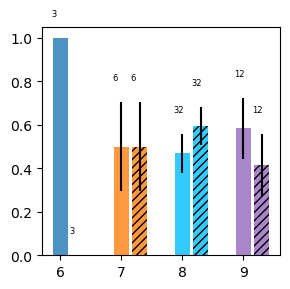

In [160]:
# 'past_reward', 'past', 'current', 'rep.', 'future', 'future_correct'
_1, p1 = correct_future_2_arm_rep(parsed_data_h, query = ["future", 'future_correct'])
_1, p2 = correct_future_2_arm_rep(parsed_data_h, query = ["past", 'past_reward'])

fig, ax = plt.subplots(1,1, figsize=(3, 3))

for animal in animals:
    data1 = p1[animal] #p(correct next in rep.) if there is 1 outer arm
    data2 = p2[animal] #p(correct next in rep.) if there is 1 outer arm

    if animal_ind == 0:
        ax.set_title("past correct & next correct \n | past & past correct")
        ax.set_ylabel("P(correct next in hippo rep.)")
        ax.set_xticks([0,1,2,3,4])
        ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals])

    # if len(data1) < 2 or len(data2) < 2:
    #     continue
    plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = True, draw_text = True)
        
    animal_ind += 1
plt.tight_layout()

In [161]:
import numpy.matlib as ml
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm
import pandas as pd

In [162]:
feature_names = ["previous", "previously_rewarded", "future", "future_correct", "same side", "switch side"]

animal_ind = 0
animals = ["julio","lewis","eliot","molly","klein"]

GLM_x = []
GLM_y = []

for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                    minimum_duration = minimum_duration, 
                                    min_posterior = min_posterior,
                                    proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]
    for ind in range(len(response_all)):

        # GLM process
        response_all_ = response_all[ind]
        #if np.sum(response_all_) > 2:
        #    continue
        features_all_ = features_all[ind]
        
        X = np.vstack(features_all_).astype("int") #reshape
    
        animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
        X_animal_category = ml.repmat(animal_category, np.shape(X)[0], 1)
        X = np.hstack((X_animal_category, X))
    
        Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all_]) #reshape

        GLM_x.append(X)
        GLM_y.append(Y)
    
GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)

feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
#feature_dict["immediate past"] = GLM_x[:,len(animals)]
#feature_dict["rewarded past"] = GLM_x[:,(len(animals)+1)]
# feature_dict["immediate next"] = GLM_x[:,(len(animals)+2)]
#feature_dict["correct future"] = GLM_x[:,(len(animals)+3)]
#feature_dict["same side"] = GLM_x[:,(len(animals)+4)]
#feature_dict["switch side"] = GLM_x[:,(len(animals)+5)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_y

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result1 = logistic_model.fit()

# 3. View the model summary
print(" ===== \n Mixed Logistics \n",logistic_result1.summary())

julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
         Current function value: 0.615057
         Iterations: 35
 ===== 
 Mixed Logistics 
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1212
Model:                          Logit   Df Residuals:                     1206
Method:                           MLE   Df Model:                            5
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                0.002539
Time:                        22:56:45   Log-Lik

In [384]:
####
# immediate past     0.1050      0.203      0.517      0.605      -0.293       0.503
# rewarded past     -0.3503      0.212     -1.652      0.099      -0.766       0.065
# immediate next     0.6106      0.179      3.412      0.001       0.260       0.961
# correct future     0.0616      0.188      0.328      0.743      -0.307       0.430

###

## End here

In [180]:
ols_model, ols_result1 = GLM_max_proportion(time_spent, remote_intervals, remote_interval_identities)

In [181]:
print(ols_result1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     11.89
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           1.43e-10
Time:                        09:36:59   Log-Likelihood:                -591.73
No. Observations:                 329   AIC:                             1195.
Df Residuals:                     323   BIC:                             1218.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.0561      0.099     20.865   

0.8800000000000001 0.03


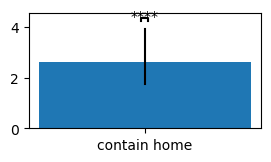

In [161]:
fig, ax1 = plt.subplots(1, 1, figsize=(3, 1.5),
                               #gridspec_kw={'height_ratios': [0.1,0.5]},
                               sharex = True)
#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

ax1.bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    ax1.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = ax1, color = 'k')

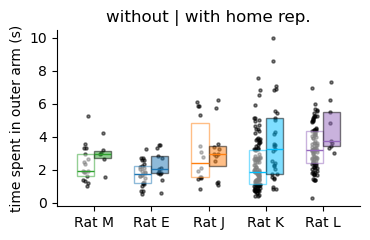

In [182]:
violin_plot(remote_intervals, remote_interval_identities, time_spent)